# Guia: NaN en batch y padding solo antes del backbone


## 1. Imports

In [1]:
from pathlib import Path 
import os
import sys
import math

import torch as tr
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
def repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'src').exists() and (p / 'data').exists():
            return p.resolve()
    raise RuntimeError('Run this notebook from inside the repo.')

ROOT = repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT)) 

# collate_fn

In [3]:
"""Collate functions for DataLoaders."""

def pad_batch(batch):
    """Batch is a dictionary with different variable lists."""

    L = [b["length"] for b in batch]
    raw_max_len = max(L)
    # Ceil max length to a multiple of 4 to keep downsampling valid.
    max_len = math.ceil(raw_max_len / 4) * 4 
    embedding_pad = tr.zeros((len(batch), batch[0]["embedding"].shape[0], max_len)) 
    conditioning_padded = tr.zeros((len(batch), batch[0]["conditioning"].shape[0], max_len, max_len))# mask (B, 1, L, L)
    mask_pad = tr.zeros((len(batch), 1, max_len, max_len), dtype=tr.bool)

    if batch[0]["contact"] is None:
        contact_pad = None
        contact_oh_pad = None
    else: 
        contact_pad = tr.zeros((len(batch), max_len, max_len))
        contact_oh_pad = tr.zeros((len(batch), 2, max_len, max_len))
        contact_oh_pad[:, 0, :, :] = 1  # default to no contact

    for k in range(len(batch)):
        embedding_pad[k, :, : L[k]] = batch[k]["embedding"]
        conditioning_padded[k, :, : L[k], : L[k]] = batch[k]["conditioning"]

        mask_pad[k, :, :L[k], :L[k]] = True
        if contact_pad is not None:
            contact_pad[k, : L[k], : L[k]] = batch[k]["contact"]
            contact_oh_pad[k, :, : L[k], : L[k]] = batch[k]["contact_oh"]

    out_batch = {"id": [b["id"] for b in batch],
                 "sequence": [b["sequence"] for b in batch],
                 "length": L,
                 "embedding": embedding_pad,
                 "conditioning": conditioning_padded,
                 "contact": contact_pad,
                 "contact_oh": contact_oh_pad,
                 "mask": mask_pad}

    return out_batch


# Model

In [4]:
def linear_betas(timesteps):
    betas = tr.linspace(0.0001, 0.01, timesteps, dtype=tr.float32)
    return betas

def cosine_betas(timesteps, s=0.02):
    """
    Cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    Better for discrete data to prevent abrupt noise injection.
    """
    steps = timesteps + 1
    x = tr.linspace(0, timesteps, steps, dtype=tr.float32)
    alphas_cumprod = tr.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    betas = tr.clip(betas, 0, 0.999)
    betas[0] = 1e-7
    return betas

def get_schedule(timesteps, get_betas, log=False):
    # beta = 1 - alpha
    betas = get_betas(timesteps)
    alphas = 1 - betas
    alphas_bar = tr.cumprod(alphas, dim=0)
    one_minus_alphas_bar = 1 - alphas_bar
    if log:
        return tr.log(betas), tr.log(alphas) , tr.log(alphas_bar), tr.log(one_minus_alphas_bar)
    else:
        return betas, alphas, alphas_bar, one_minus_alphas_bar

def extract(a, t, x_shape):
    """Extract values from `a` at indices `t` and reshape to match `x_shape`."""
    batch_size = t.shape[0]
    out = a.gather(-1, t)  # Extract values at indices `t`
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))  # Reshape to match `x_shape`

# ref https://github.com/ehoogeboom/multinomial_diffusion/blob/main/diffusion_utils/diffusion_multinomial.py
# ref 2 https://github.com/lucidrains/denoising-diffusion-pytorch/blob/5989f4c77eafcdc6be0fb4739f0f277a6dd7f7d8/denoising_diffusion_pytorch/denoising_diffusion_pytorch.py

class DiffusionModel(nn.Module):
    def __init__(self, num_classes, time_steps, model, schedule="cosine", **kwargs):
        super().__init__()
        self.diffuser = model(**kwargs)
        self.num_classes = num_classes
        self.time_steps = time_steps

        # about buffers: https://discuss.pytorch.org/t/what-is-the-difference-between-register-buffer-and-register-parameter-of-nn-module/32723
        # Register buffers with shape (T, 1, 1, 1).
        # This enables direct broadcasting over [B, C, H, W] without .view().
        if schedule == "linear":
            beta_fn = linear_betas
        else:
            beta_fn = cosine_betas
        betas, alphas, alphas_bar, one_minus_alphas_bar = get_schedule(time_steps, beta_fn)
        self.register_buffer("one_minus_alphas", 1 - alphas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_bar", alphas_bar)
        self.register_buffer("one_minus_alphas_bar", one_minus_alphas_bar)

        # Optional buffer for stochastic NLL (if needed).

    def x_to_one_hot(self, x, from_one_hot = True):
        if from_one_hot:
            return x.float()
        else:
            # x is [B, H, W], convert to one-hot [B, C, H, W]
            return F.one_hot(x, num_classes=self.num_classes).permute(0, 3, 1, 2).float()

    def _lengths_to_mask(self, lengths, padded_length, device=None):
        if lengths is None:
            return None
        if device is None:
            device = self.alphas.device
        lengths_t = tr.as_tensor(lengths, device=device, dtype=tr.long)
        rng = tr.arange(padded_length, device=device)
        valid_1d = rng[None, :] < lengths_t[:, None]
        valid_2d = valid_1d[:, :, None] & valid_1d[:, None, :]
        return valid_2d.unsqueeze(1)

    def _prepare_backbone_inputs(self, xt_input, condition, lengths=None):
        xt_input = self.x_to_one_hot(xt_input, False)
        if lengths is None:
            return xt_input, condition

        mask = self._lengths_to_mask(lengths, xt_input.shape[-1], device=xt_input.device)
        xt_fill = tr.zeros_like(xt_input) # [B, C, H, W]
        xt_fill[:, 0, :, :] = 1.0
        valid_xt = mask.expand_as(xt_input)
        valid_cond = mask.expand_as(condition)

        xt_backbone = tr.where(valid_xt, xt_input, xt_fill)
        cond_backbone = tr.where(valid_cond, condition, tr.zeros_like(condition))
        return xt_backbone, cond_backbone
    
    def _gumbel_sample(self, logits, dim=1):
        uniform = tr.rand_like(logits)
        gumbel_noise = -tr.log(-tr.log(uniform + 1e-30) + 1e-30)
        sampled = (gumbel_noise + logits).argmax(dim=dim) # [B, L, L]
        return sampled
    
    def sample_categorical(self, logits, lengths=None):
        if lengths is None:
            return  self._gumbel_sample(logits, dim=1)
             

        B, C, L, _ = logits.shape
        out = tr.zeros(B, L, L, device=logits.device, dtype=tr.long)

        for b, l in enumerate(lengths):
            l = int(l)
            logits_b = logits[b, :, :l, :l]
            out[b, :l, :l] = self._gumbel_sample(logits_b, dim=0)
        return out
    
    
    def sample_from_probs(self, probs, lengths=None):
        # probs: [B, C, H, W]
        probs = tr.clamp(probs, min=1e-30)
        probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-8)
        logits = tr.log(probs) 
        return self.sample_categorical(logits, lengths=lengths)  #  [B,H,W]
    

    def q_pred(self, x0, t):
        """Given x0 and time t, compute q(xt|x0)."""
        
        alphas_bar = extract(self.alphas_bar, t, x0.shape)
        one_minus_alphas_bar = extract(self.one_minus_alphas_bar, t, x0.shape)
        probs = alphas_bar * x0 + one_minus_alphas_bar / self.num_classes
        return probs # [B, C, H, W]

    def q_step(self, xt_1, t):
        """Given xt_1 and time t, compute q(xt|xt_1)."""
        xt_1_one_hot = self.x_to_one_hot(xt_1, from_one_hot=False)
 
        alphas_t = extract(self.alphas, t, xt_1_one_hot.shape)
        one_minus_alpha_t = extract(self.one_minus_alphas, t, xt_1_one_hot.shape)
        qxt = alphas_t * xt_1_one_hot + one_minus_alpha_t / self.num_classes
        return qxt # [B, C, H, W]

    def q_posterior(self, x0_oh, xt, t):
        """Given xt, x0 and time t, compute q(xt-1|xt,x0)."""
        
        x0_one_hot = self.x_to_one_hot(x0_oh, from_one_hot=True)

        t_1 = tr.clamp(t - 1, min=0)
        qxt_1_given_x0 = self.q_pred(x0_one_hot, t_1)
        qxt_1_given_x0 = tr.where(
            t.view(-1, 1, 1, 1) == 0,
            x0_one_hot,
            qxt_1_given_x0,
        )
        qxt_given_xt_1 = self.q_step(xt, t)
        posterior = qxt_1_given_x0 * qxt_given_xt_1
        posterior = posterior / (posterior.sum(dim=1, keepdim=True) + 1e-8) # check nansum
        return posterior # [B, C, H, W]

    def predict_start(self, xt, t, condition, lengths=None, return_logits=False): 
            # takes xt [B,H,W] and condition [B,C,H,W]
            xt_input, condition = self._prepare_backbone_inputs(xt, condition, lengths=lengths)
            # now xt_input is [B,C,H,W] one-hot, with padding handled, and condition is also padded
            unet_input = tr.cat([xt_input, condition], dim=1)
            out = self.diffuser(unet_input, t)

            if return_logits:
                return out
            return F.softmax(out, dim=1) # [B, C, H, W]

    def pred_p_xt_1_from_xt(self, xt, t, condition, lengths=None):
        pred = self.predict_start(xt, t, condition, lengths=lengths)
        return self.q_posterior(pred, xt, t)

    def q_sample(self, x0_oh, t, lengths=None):
        qxt_probs = self.q_pred(x0_oh, t)
        qxt_probs = tr.clamp(qxt_probs, min=1e-20, max=1.0) 
        return self.sample_from_probs(qxt_probs, lengths=lengths)

    @tr.no_grad()
    def p_sample(self, xt, t, condition, lengths=None):
        posterior_probs = self.pred_p_xt_1_from_xt(xt, t, condition, lengths=lengths)
        out = self.sample_from_probs(posterior_probs, lengths=lengths)
        return out

    @tr.no_grad()
    def p_sample_loop(self, shape, condition, lengths=None):
        """Sample an image from pure noise."""
        batch_size = shape[0]
        device = self.alphas.device
        xt = tr.randint(0, self.num_classes, shape, device=device).long()

        for t in reversed(range(0, self.time_steps)):
            t_batch = tr.full((batch_size,), t, device=device, dtype=tr.long)
            xt = self.p_sample(xt, t_batch, condition, lengths=lengths)
        return xt

    @tr.no_grad()
    def sample(self, condition, lengths=None):
        shape = (condition.shape[0], condition.shape[2], condition.shape[3])
        samples = self.p_sample_loop(shape, condition, lengths=lengths)
        return samples

    def compute_vlb(self, x0_oh, xt, t, condition, lengths=None):
            true_posterior = self.q_posterior(x0_oh, xt, t)
            pred_x0_probs = self.predict_start(xt, t, condition, lengths=lengths, return_logits=False)
            pred_posterior = self.q_posterior(pred_x0_probs, xt, t)

            eps = 1e-8
            true_posterior = tr.clamp(true_posterior, min=eps, max=1.0)
            pred_posterior = tr.clamp(pred_posterior, min=eps, max=1.0)

            kl = true_posterior * (tr.log(true_posterior) - tr.log(pred_posterior))
            kl_pixelwise = tr.sum(kl, dim=1) 

            if lengths is not None:
                valid_means = []
                for b, l in enumerate(lengths):
                    l = int(l)
                    valid_means.append(kl_pixelwise[b, :l, :l].mean())
                return tr.stack(valid_means).mean()

            return kl_pixelwise.mean()

    def forward_all_timesteps(self, x0_oh, condition, lengths=None):
        """Calculate the total loss by summing VLB over all timesteps."""
        batch_size = x0_oh.shape[0]
        device = x0_oh.device
        total_loss = 0

        for t_step in range(self.time_steps):
            t = tr.full((batch_size,), t_step, device=device).long()
            xt = self.q_sample(x0_oh, t, lengths=lengths)
            loss_t = self.compute_vlb(x0_oh, xt, t, condition, lengths=lengths)
            total_loss += loss_t

        return total_loss


# Implementacion


In [20]:
from src.data import build_dataloader
from src.layers.simpleunet import SimpleUNet
from src.diffusion import DiffusionModel
tr.set_printoptions(precision=4, sci_mode=False)

## 2. Cargar un batch con padding

In [21]:
# LOAD CONFIG
# configs/train/default.yaml
import yaml
config = yaml.safe_load((ROOT / 'configs' / 'train' / 'default.yaml').read_text())
# make dict
config["training"]["max_epochs"] = 1

In [22]:

loader = build_dataloader(config, partition="train")
# loader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=pad_batch, num_workers=0)

for batch_id, batch in enumerate(loader):
    max_len = batch['contact_oh'].shape[-1]
    idx = next((i for i, l in enumerate(batch['length']) if l < 0.9 * max_len), None)
    if idx is not None:
        break

seq_len = batch['length'][idx]
print('batch:', batch_id)
print('lengths:', batch['length'])
print('sample idx:', idx, 'seq_len:', seq_len, 'max_len:', max_len)

batch: 0
lengths: [75, 111, 120, 118]
sample idx: 0 seq_len: 75 max_len: 120


## 3. Ver el padding real

valid pixel: tensor([1., 0.])  shape:  torch.Size([2, 120, 120])
evaluation at seq_len: 75
padded pixel: tensor([1., 0.])
derived mask padded pixel: tensor(False)  shape  torch.Size([120, 120])


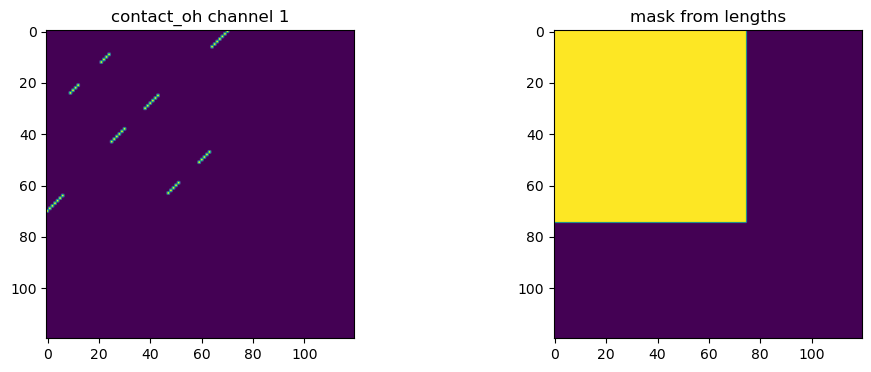

In [23]:
x0_real = batch['contact_oh'][idx:idx + 1].float()
padded_length = x0_real.shape[-1]
rng = tr.arange(padded_length)
valid_1d = rng < seq_len
mask_real = (valid_1d[:, None] & valid_1d[None, :]).unsqueeze(0).unsqueeze(0)
cond = batch['conditioning'][idx:idx + 1].float()
contact_real = x0_real[0]
mask2d = mask_real[0, 0]

print('valid pixel:', contact_real[:, 0, 0], ' shape: ', contact_real.shape)
print('evaluation at seq_len:', seq_len)
print('padded pixel:', contact_real[:, seq_len, seq_len])
print('derived mask padded pixel:', mask2d[seq_len, seq_len], " shape ", mask2d.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(contact_real[1])
axes[0].set_title('contact_oh channel 1')
axes[1].imshow(mask2d)
axes[1].set_title('mask from lengths')
plt.show()

## 4. `q_pred` mantiene `NaN` fuera de mascara


In [24]:
# weights_path = "/home/gkulemeyer/Documents/Repos/RNADiffusion/logs/ArchiveII_test_zeropadd/sim70/t25/m64/20260325-0117_model_64_Fold0/checkpoints/best.ckpt"
# weights = tr.load(weights_path, map_location='cpu')
# weights["state_dict"]

q valid pixel: tensor([    1.0000,     0.0000])
q padded pixel: tensor([    1.0000,     0.0000])


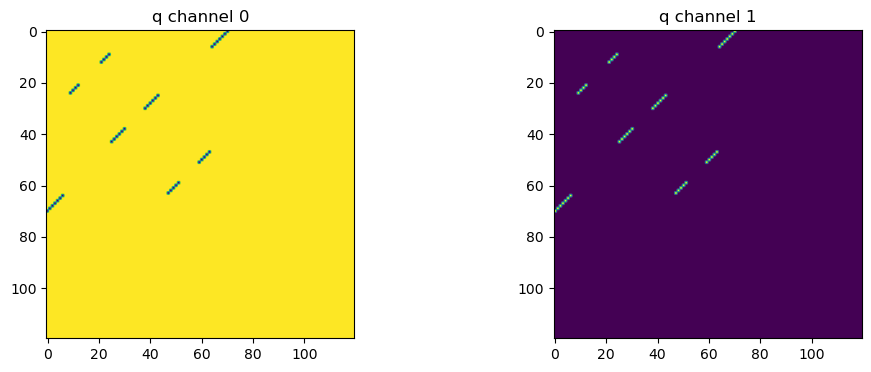

In [25]:
model = DiffusionModel(
    num_classes=2,
    time_steps=25,
    model=SimpleUNet,
    in_channels=18,
    out_channels=2,
    base_dim=64,
).eval() 
# sd = tr.load(weights_path, map_location='cpu')

# sd = {k.removeprefix("model."): v for k, v in sd["state_dict"].items()}

# model.load_state_dict(sd) 

time0 = tr.tensor([0])
q = model.q_pred(x0_real, time0)

print('q valid pixel:', q[0, :, 0, 0])
print('q padded pixel:', q[0, :, seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(q[0, 0])
axes[0].set_title('q channel 0')
axes[1].imshow(q[0, 1])
axes[1].set_title('q channel 1')
plt.show()

## 5. Saneo localizado justo antes del backbone


In [26]:
q_sum = q.nansum(dim=1)

print('sum valid pixel:', q_sum[0, 0, 0])
print('sum padded pixel:', q_sum[0, seq_len, seq_len])
print('q finite in valid region:', tr.isfinite(q[:, :, :seq_len, :seq_len]).all())
print('q finite in padding:', tr.isfinite(q[0, :, seq_len, seq_len]))


sum valid pixel: tensor(1.)
sum padded pixel: tensor(1.)
q finite in valid region: tensor(True)
q finite in padding: tensor([True, True])


## 6. Forward diffusion + loss solo en pixeles validos


In [27]:
length = batch['length'][idx]
time = tr.tensor([model.time_steps // 2])
q = model.q_pred(x0_real, time)
print(f"q shape: {q.shape}")
xt = model.q_sample(x0_real, time, lengths=[length]) 
print(f"xt shape: {xt.shape}")
raw_post = model.q_pred(x0_real, tr.clamp(time - 1, min=0)) * model.q_step(xt, time) # norm 
print(f"raw_post shape: {raw_post.shape}")
post = model.q_posterior(x0_real, xt, time)
print(f"post shape: {post.shape}")
xt_backbone, cond_backbone = model._prepare_backbone_inputs(xt, cond, lengths=[length])
pred_x0 = model.predict_start(xt, time, cond, lengths=[length])
vlb = model.compute_vlb(x0_real, xt, time, cond, lengths=[length])
print(xt_backbone.shape, cond_backbone.shape, pred_x0.shape)
print('xt padded before backbone:', xt[0, seq_len, seq_len])
print('xt padded at backbone:', xt_backbone[0, :, seq_len, seq_len])
print('conditioning padded before backbone:', cond[0, :4, seq_len, seq_len])
print('conditioning padded at backbone:', cond_backbone[0, :4, seq_len, seq_len])
print('predict_start padded:', pred_x0[0, :, seq_len, seq_len], 'sum =', pred_x0[0, :, seq_len, seq_len].sum())
print('vlb finite:', tr.isfinite(vlb), 'value =', vlb)


q shape: torch.Size([1, 2, 120, 120])
xt shape: torch.Size([1, 120, 120])
raw_post shape: torch.Size([1, 2, 120, 120])
post shape: torch.Size([1, 2, 120, 120])
torch.Size([1, 2, 120, 120]) torch.Size([1, 16, 120, 120]) torch.Size([1, 2, 120, 120])
xt padded before backbone: tensor(0)
xt padded at backbone: tensor([1., 0.])
conditioning padded before backbone: tensor([0., 0., 0., 0.])
conditioning padded at backbone: tensor([0., 0., 0., 0.])
predict_start padded: tensor([0.5662, 0.4338], grad_fn=<SelectBackward0>) sum = tensor(1., grad_fn=<SumBackward0>)
vlb finite: tensor(True) value = tensor(0.0155, grad_fn=<MeanBackward0>)


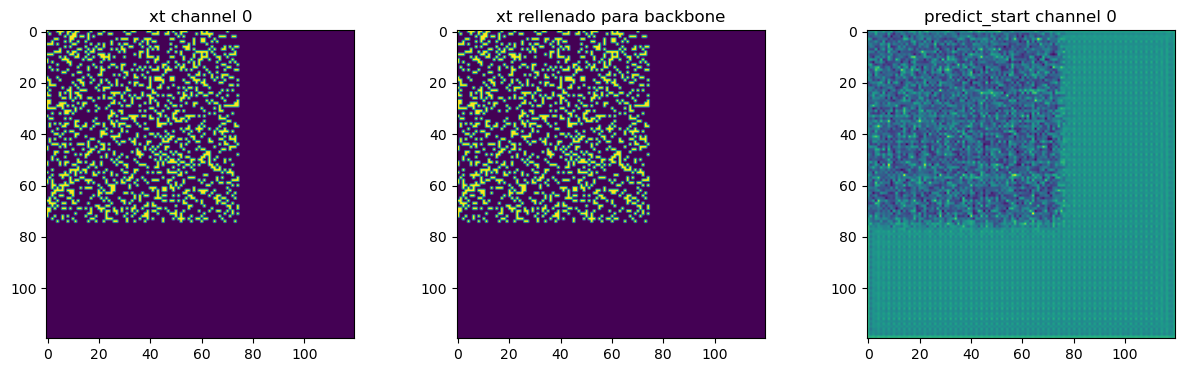

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(xt[0])
axes[0].set_title('xt channel 0')
axes[1].imshow(xt_backbone[0, 1])
axes[1].set_title('xt rellenado para backbone')
axes[2].imshow(pred_x0[0, 1].detach().numpy())
axes[2].set_title('predict_start channel 0')
plt.show()


 shapes: q: torch.Size([1, 2, 120, 120]), xt: torch.Size([1, 120, 120]), xt_backbone: torch.Size([1, 2, 120, 120]), pred: torch.Size([1, 2, 120, 120])
 shapes: q: torch.Size([1, 2, 120, 120]), xt: torch.Size([1, 120, 120]), xt_backbone: torch.Size([1, 2, 120, 120]), pred: torch.Size([1, 2, 120, 120])
 shapes: q: torch.Size([1, 2, 120, 120]), xt: torch.Size([1, 120, 120]), xt_backbone: torch.Size([1, 2, 120, 120]), pred: torch.Size([1, 2, 120, 120])
 shapes: q: torch.Size([1, 2, 120, 120]), xt: torch.Size([1, 120, 120]), xt_backbone: torch.Size([1, 2, 120, 120]), pred: torch.Size([1, 2, 120, 120])
 shapes: q: torch.Size([1, 2, 120, 120]), xt: torch.Size([1, 120, 120]), xt_backbone: torch.Size([1, 2, 120, 120]), pred: torch.Size([1, 2, 120, 120])


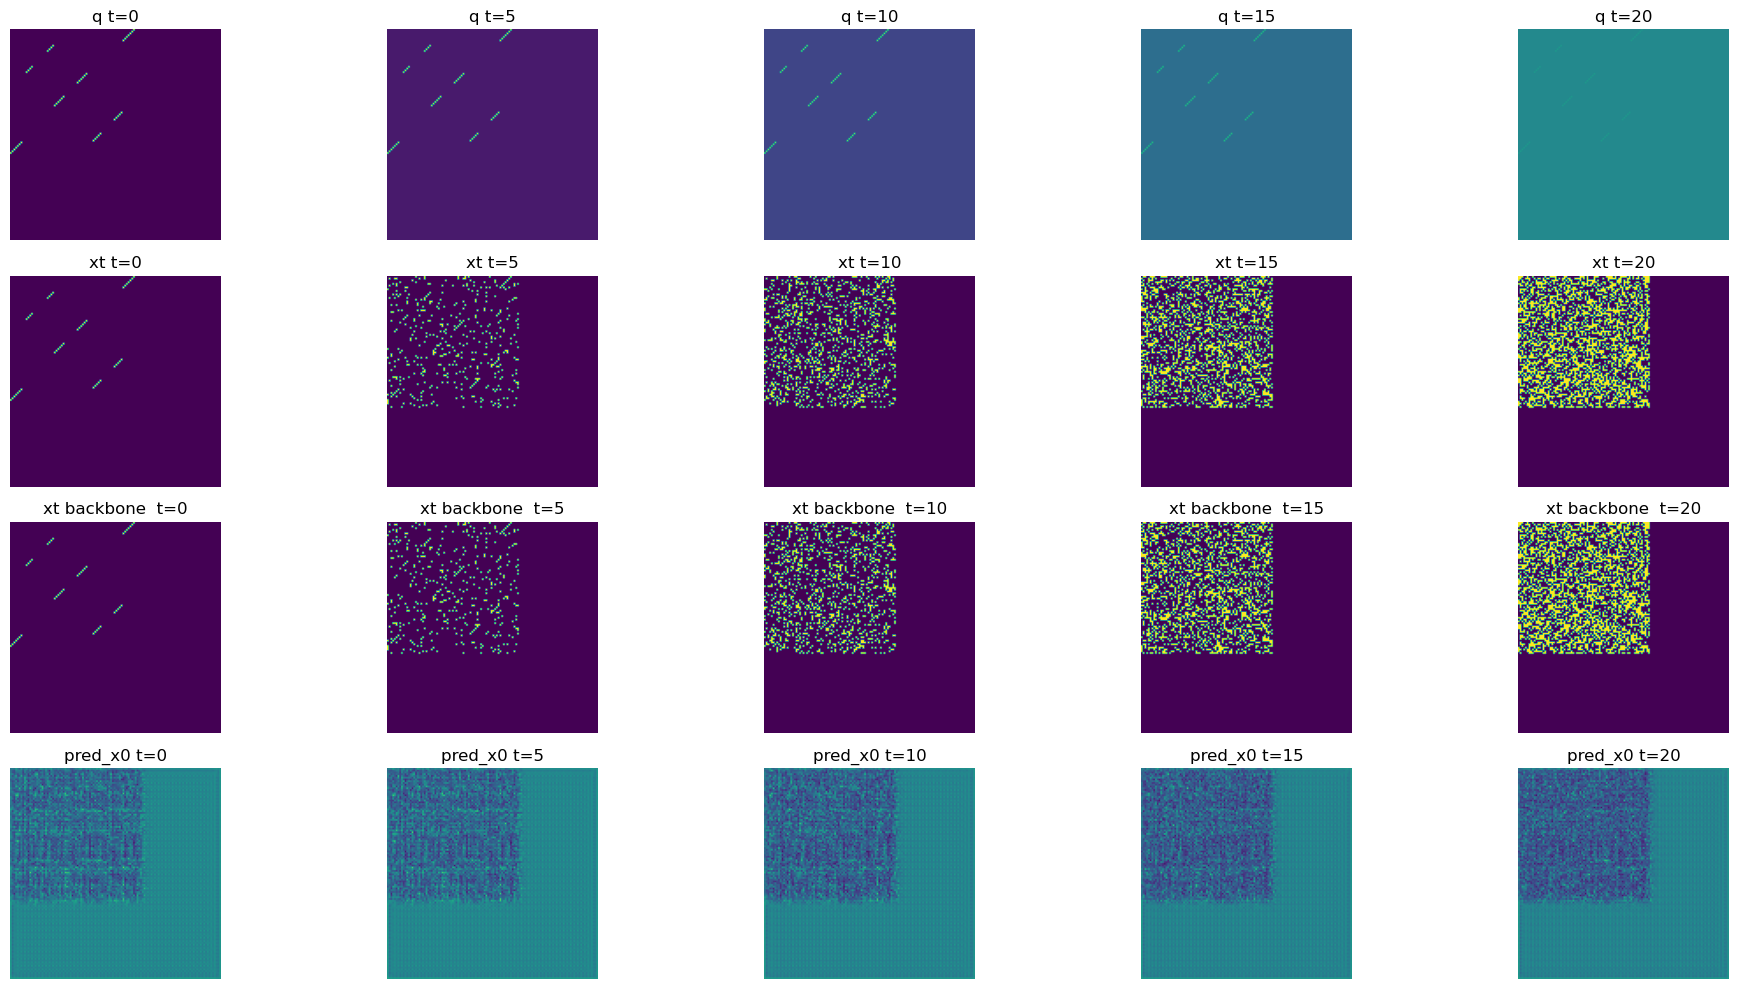

In [29]:
times = [tr.tensor([t]) for t in range(0, model.time_steps, 5)]
qt = [model.q_pred(x0_real, time_t) for time_t in times]
xt_t = [model.q_sample(x0_real, time_t, lengths=[length]) for time_t in times]
xt_t_backbone = []
for i, (xt, time_t) in enumerate(zip(xt_t, times)):
    xt_backbone, _ = model._prepare_backbone_inputs(xt, cond, lengths=[length])
    xt_t_backbone.append(xt_backbone)
pred_t = [model.predict_start(xt_t, time_t, cond, lengths=[length]) for xt_t, time_t in zip(xt_t, times)]

# plot (4, times) and show q, xt and xt_backbone, pred
fig, axes = plt.subplots(4, len(times), figsize=(4 * len(times), 10))
for i, time_t in enumerate(times):
    print(f" shapes: q: {qt[i].shape}, xt: {xt_t[i].shape}, xt_backbone: {xt_t_backbone[i].shape}, pred: {pred_t[i].shape}")
    axes[0,i].imshow(qt[i][0, 1], vmin=0, vmax=1)
    axes[0, i].set_title(f'q t={time_t.item()}')
    axes[1, i].imshow(xt_t[i][0], vmin=0, vmax=1) 
    axes[1, i].set_title(f'xt t={time_t.item()}')
    axes[2, i].imshow(xt_t_backbone[i][0, 1], vmin=0, vmax=1)
    axes[2, i].set_title(f'xt backbone  t={time_t.item()}')
    axes[3, i].imshow(pred_t[i][0, 1].detach().numpy(), vmin=0, vmax=1)
    axes[3, i].set_title(f'pred_x0 t={time_t.item()}')
for ax in axes.flatten():
    ax.axis('off')
fig.tight_layout()
plt.show()

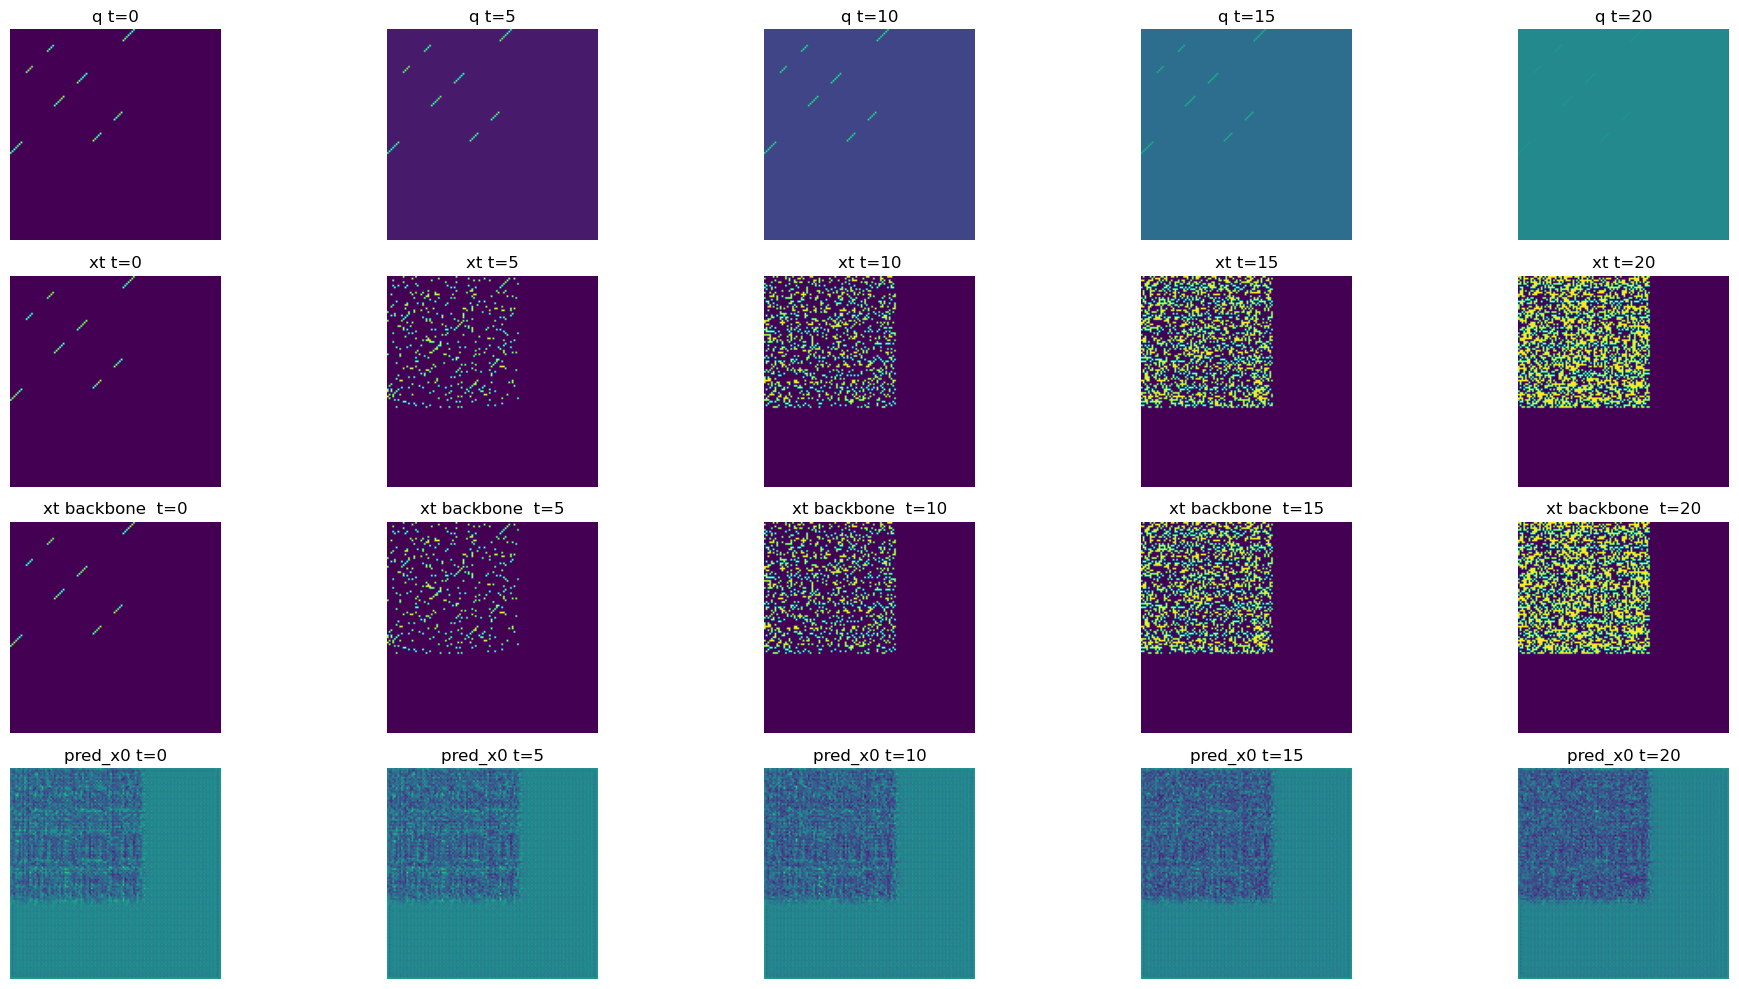

In [30]:
times = [tr.tensor([t]) for t in range(0, model.time_steps, 5)]
# plot (4, times) and show q, xt and xt_backbone, pred
fig, axes = plt.subplots(4, len(times), figsize=(4 * len(times), 10))
for i, time_t in enumerate(times):
    qt = model.q_pred(x0_real, time_t)
    xt_t = model.q_sample(x0_real, time_t, lengths=[length])
    xt_t_backbone, _ = model._prepare_backbone_inputs(xt_t, cond, lengths=[length])
    pred_t = model.predict_start(xt_t, time_t, cond, lengths=[length]) 
    axes[0 ,i].imshow(qt[0, 1], vmin=0, vmax=1)
    axes[0, i].set_title(f'q t={time_t.item()}')
    axes[1, i].imshow(xt_t[0], vmin=0, vmax=1)
    axes[1, i].set_title(f'xt t={time_t.item()}')
    axes[2, i].imshow(xt_t_backbone[0, 1], vmin=0, vmax=1)
    axes[2, i].set_title(f'xt backbone  t={time_t.item()}')
    axes[3, i].imshow(pred_t[0, 1].detach().numpy(), vmin=0, vmax=1)
    axes[3, i].set_title(f'pred_x0 t={time_t.item()}')
for ax in axes.flatten():
    ax.axis('off')
fig.tight_layout()
plt.show()

In [31]:
print('contact padded:', x0_real[0, :, seq_len, seq_len])
print('conditioning padded:', cond[0, :4, seq_len, seq_len])
print('mask padded:', mask_real[0, 0, seq_len, seq_len])


contact padded: tensor([1., 0.])
conditioning padded: tensor([0., 0., 0., 0.])
mask padded: tensor(False)


In [32]:
true_posterior = model.q_posterior(x0_real, xt, time)
pred_posterior = model.q_posterior(pred_x0, xt, time)
eps = 1e-8
true_posterior = tr.clamp(true_posterior, min=eps, max=1.0)
pred_posterior = tr.clamp(pred_posterior, min=eps, max=1.0)
kl = true_posterior * (tr.log(true_posterior) - tr.log(pred_posterior))
kl_pixelwise = tr.sum(kl, dim=1)
print('kl_pixelwise shape:', kl_pixelwise)
kl_pixelwise_nan = tr.nansum(kl, dim=1)
print('kl_pixelwise nan shape:', kl_pixelwise_nan)

print('raw padded kl:', kl_pixelwise[0, seq_len, seq_len])
print('masked with multiplication:', (kl_pixelwise * mask_real.squeeze(1))[0, seq_len, seq_len])
print('valid mean with boolean indexing:', kl_pixelwise[mask_real.squeeze(1)].mean())


kl_pixelwise shape: tensor([[[0.0490, 0.0557, 0.0635,  ..., 0.0217, 0.0174, 0.0212],
         [0.0300, 0.0348, 0.0053,  ..., 0.0151, 0.0137, 0.0200],
         [0.0380, 0.0038, 0.0307,  ..., 0.0164, 0.0130, 0.0197],
         ...,
         [0.0207, 0.0121, 0.0149,  ..., 0.0122, 0.0139, 0.0205],
         [0.0231, 0.0120, 0.0162,  ..., 0.0124, 0.0147, 0.0182],
         [0.0264, 0.0218, 0.0238,  ..., 0.0210, 0.0195, 0.0227]]],
       grad_fn=<SumBackward1>)
kl_pixelwise nan shape: tensor([[[0.0490, 0.0557, 0.0635,  ..., 0.0217, 0.0174, 0.0212],
         [0.0300, 0.0348, 0.0053,  ..., 0.0151, 0.0137, 0.0200],
         [0.0380, 0.0038, 0.0307,  ..., 0.0164, 0.0130, 0.0197],
         ...,
         [0.0207, 0.0121, 0.0149,  ..., 0.0122, 0.0139, 0.0205],
         [0.0231, 0.0120, 0.0162,  ..., 0.0124, 0.0147, 0.0182],
         [0.0264, 0.0218, 0.0238,  ..., 0.0210, 0.0195, 0.0227]]],
       grad_fn=<NansumBackward0>)
raw padded kl: tensor(0.0140, grad_fn=<SelectBackward0>)
masked with multiplica

In [33]:

def _sample_batch(model, conditioning, lengths, num_samples, base_seed, chunk_size):
    batch_size = conditioning.shape[0]
    # mask = tr.stack([_get_mask2d_from_length(length, conditioning.shape[-1]) for length in lengths], dim=0)
    chunks = []
    generated = 0

    while generated < num_samples:
        current_chunk = min(chunk_size, num_samples - generated)
        tr.manual_seed(base_seed + generated)
        expanded_conditioning = conditioning.repeat_interleave(current_chunk, dim=0)
        # expanded_mask = mask.repeat_interleave(current_chunk, dim=0)

        with tr.no_grad():
            sampled = model.sample(expanded_conditioning, lengths=lengths)

        if sampled.ndim == 4:
            sampled = sampled.argmax(dim=1)
        elif sampled.ndim == 2:
            sampled = sampled.unsqueeze(0)
        if sampled.ndim != 3:
            raise ValueError(f"Unexpected sampled tensor shape: {tuple(sampled.shape)}")

        sampled = sampled.reshape(batch_size, current_chunk, sampled.shape[-2], sampled.shape[-1])
        chunks.append(sampled.cpu().to(tr.int8))
        generated += current_chunk

    return tr.cat(chunks, dim=1)

In [39]:
# batch["id"]
loader

In [41]:
base_seed = 42
chunk_size=1
num_samples = 2
from tqdm import tqdm
model.eval() 
device = next(model.parameters()).device
seeds = [base_seed + index for index in range(num_samples)]
save_dir = ROOT / "tmp"
save_dir.mkdir(exist_ok=True)
save_paths = [save_dir / f"sample_{batch_id}_{index}.pt" for batch_id in range(len(loader)) for index in range(num_samples)]

# for batch in tqdm(loader, desc="Generating samples", leave=False):
batch_ids = batch["id"] 
# pending_indices = [index for index, path in enumerate(save_paths) if not path.exists()]
# if not pending_indices:
#     continue

conditioning = batch["conditioning"].to(device) 
lengths = tr.tensor(batch["length"], dtype=tr.long).to(device)
sampled = _sample_batch(
    model=model,
    conditioning=conditioning,
    lengths=lengths,
    num_samples=num_samples,
    base_seed=base_seed,
    chunk_size=chunk_size,
)

# for i, batch_index in enumerate(pending_indices):
    # tr.save(
    #     {
    #         "samples": sampled[i],
    #         "seeds": seeds,
    #         "target": batch["contact_oh"][batch_index].cpu().to(tr.int8),
    #         "length": int(batch["length"][batch_index]),
    #     },
    #     save_paths[batch_index],
    # )
    
# save_dir.rmdir()

In [46]:
sampled.shape, lengths

(torch.Size([4, 2, 120, 120]), tensor([ 75, 111, 120, 118]))

torch.Size([2, 120, 120])

## 7. Reverse sampling con mascara


In [ ]:
p_step = model.p_sample(xt, time, cond, lengths=[length])

print('p_sample valid:', p_step[0, 0, 0])
print('p_sample padded:', p_step[0, seq_len, seq_len])


p_sample valid: tensor(1)
p_sample padded: tensor(0)


In [ ]:
pred_x0.shape

torch.Size([1, 2, 120, 120])

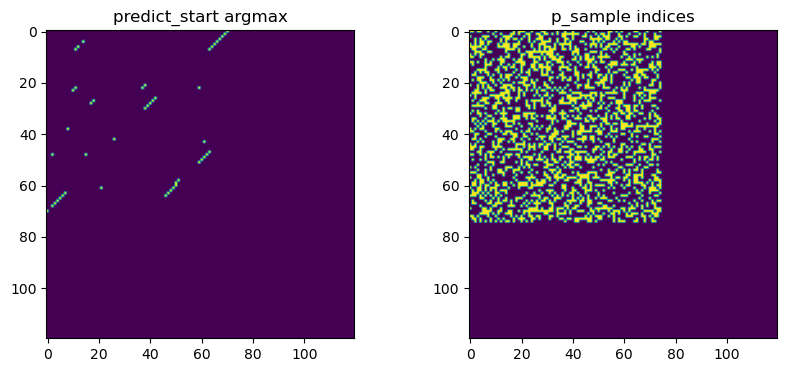

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(tr.argmax(pred_x0[0], dim=0))
axes[0].set_title('predict_start argmax')
axes[1].imshow(p_step[0])
axes[1].set_title('p_sample indices')
plt.show()


## 8. Sampling completo


In [ ]:
pred_x0 = model.predict_start(xt, time, cond, lengths=[length])
sample_full = model.sample(cond, lengths=[length])

print('predict_start padded:', pred_x0[0, :, seq_len, seq_len], 'sum =', pred_x0[0, :, seq_len, seq_len].sum())
print('_sample padded:', sample_full[0, seq_len, seq_len])


predict_start padded: tensor([    0.9998,     0.0002], grad_fn=<SelectBackward0>) sum = tensor(1., grad_fn=<SumBackward0>)
_sample padded: tensor(0)


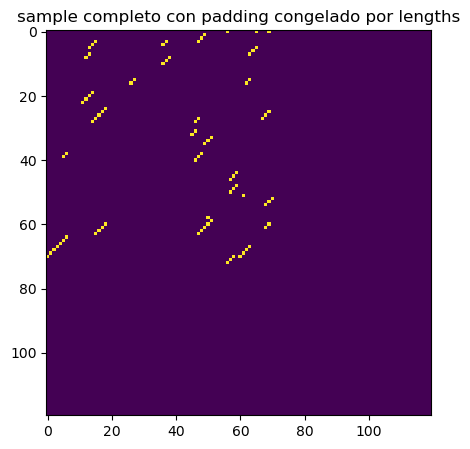

In [ ]:
tr.manual_seed(0)
sample_full = model.sample(cond, lengths=[length])

plt.figure(figsize=(6, 5))
plt.imshow(sample_full[0])
plt.title('sample completo con padding congelado por lengths')
plt.show()


In [ ]:
loss = model.forward_all_timesteps(x0_real, cond, lengths=[length])
loss

tensor(0.0133, grad_fn=<AddBackward0>)